# EDA — Weekend Gap Prediction

**Dataset:** `structured_csv_data_files/fetched_data/dataset_mon_fri.csv`  
**Goal:** Binary classification — predict if Monday's opening price is higher than the previous Friday's closing price.

**Target variable — `GapUp`:**
- `1` = gap up: Monday Open > previous Friday Close
- `0` = gap down: Monday Open ≤ previous Friday Close

**Gap Magnitude explained:**  
`(Monday Open − Friday Close) / Friday Close`  
This is the *continuous* version of the target. A +0.01% gap and a +5% gap are both `GapUp=1` but are very different events — magnitude tells us the strength of the signal, not just direction. We use it during EDA to understand the scale of weekend moves before collapsing them to binary.

---
**Notebook order:**  
1. Load data and create target  
2. Dataset overview  
3. Target variable analysis  
4. Missing value deep-dive (understand *why* values are missing)  
5. Missing value handling (imputation / dropping decisions)  
6. Feature distributions by class  
7. Summary statistics and effect sizes  
8. Correlation analysis  
9. Temporal patterns  
10. Outlier detection  
11. Save clean dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
%matplotlib inline

## 1. Load Data & Create Target Variable

The raw file contains both Monday and Friday rows for each ticker. The target is constructed by pairing each Monday row with the immediately preceding Friday row *for the same ticker*, using a row-shift within each ticker group. This is safer than joining on WeekOfYear because it correctly handles year boundaries and weeks where a Monday or Friday was a market holiday.

In [ ]:

df_raw = pd.read_csv('../../structured_csv_data_files/fetched_data/dataset_mon_fri.csv')
df_raw['Date'] = pd.to_datetime(df_raw['Date'], utc=True)
df_raw = df_raw.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f'Raw shape: {df_raw.shape}')
print(f'Date range: {df_raw["Date"].min().date()} to {df_raw["Date"].max().date()}')
print(f'Tickers ({df_raw["Ticker"].nunique()}): {sorted(df_raw["Ticker"].unique())}')
print(f'Day counts: {df_raw["DayOfWeek"].value_counts().to_dict()}')

Raw shape: (24894, 41)
Date range: 2016-03-28 to 2024-12-30
Tickers (25): ['ADBE', 'ADP', 'ADSK', 'AKAM', 'CDNS', 'CPAY', 'CRM', 'FFIV', 'FICO', 'FTNT', 'GEN', 'GWRE', 'HUBS', 'INTU', 'NOW', 'NTAP', 'PANW', 'PAYX', 'PTC', 'ROP', 'SNPS', 'SSNC', 'TYL', 'VRSN', 'WDAY']
Day counts: {'Friday': 12945, 'Monday': 11949}


In [ ]:
# Build the target variable.
#


df_raw['_PrevDay']      = df_raw.groupby('Ticker')['DayOfWeek'].shift(1)
df_raw['_PrevFriClose'] = df_raw.groupby('Ticker')['Close'].shift(1)

mondays    = df_raw[df_raw['DayOfWeek'] == 'Monday'].copy()
valid_pair = mondays['_PrevDay'] == 'Friday'

mondays['PrevFriClose'] = np.where(valid_pair, mondays['_PrevFriClose'], np.nan)
mondays['GapMagnitude'] = (mondays['Open'] - mondays['PrevFriClose']) / mondays['PrevFriClose']
mondays['GapUp']        = np.where(
    mondays['PrevFriClose'].notna(),
    (mondays['Open'] > mondays['PrevFriClose']).astype(int),
    np.nan
)
mondays = mondays.drop(columns=['_PrevDay', '_PrevFriClose'])

print(f'Monday rows total:           {len(mondays):,}')
print(f'Valid Mon-Fri pairs:         {valid_pair.sum():,}')
print(f'Missing preceding Friday:    {(~valid_pair).sum():,}  (first obs per ticker or holiday gap)')

Monday rows total:           11,949
Valid Mon-Fri pairs:         9,925
Missing preceding Friday:    2,024  (first obs per ticker or holiday gap)


## 2. Dataset Overview

We restrict to Monday rows that have a valid target label. This is our working dataset for all downstream analysis.

In [ ]:
# Drop rows without a valid target and cast GapUp to int.

df = mondays.dropna(subset=['GapUp']).copy()
df['GapUp']     = df['GapUp'].astype(int)
df['Date_notz'] = df['Date'].dt.tz_localize(None)

print(f'Working dataset shape: {df.shape}')
print(f'Rows per ticker (mean): {len(df) / df["Ticker"].nunique():.0f}')
display(df.dtypes.value_counts().rename('dtype counts'))

Working dataset shape: (9925, 45)
Rows per ticker (mean): 397


float64                34
int64                   6
object                  3
datetime64[ns, UTC]     1
datetime64[ns]          1
Name: dtype counts, dtype: int64

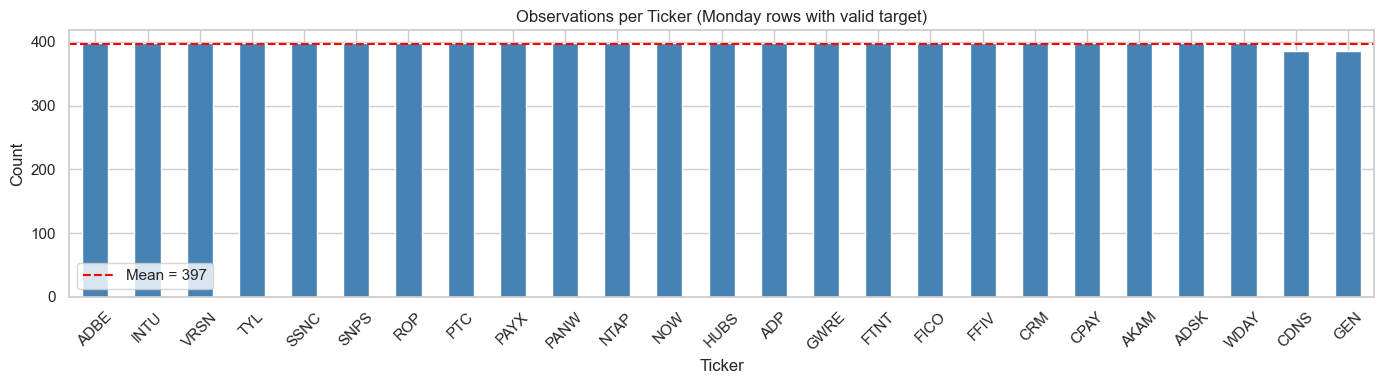

In [ ]:
# Observations per ticker.

obs = df.groupby('Ticker').size().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 4))
obs.plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(obs.mean(), color='red', linestyle='--', label=f'Mean = {obs.mean():.0f}')
ax.set_title('Observations per Ticker (Monday rows with valid target)')
ax.set_ylabel('Count')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

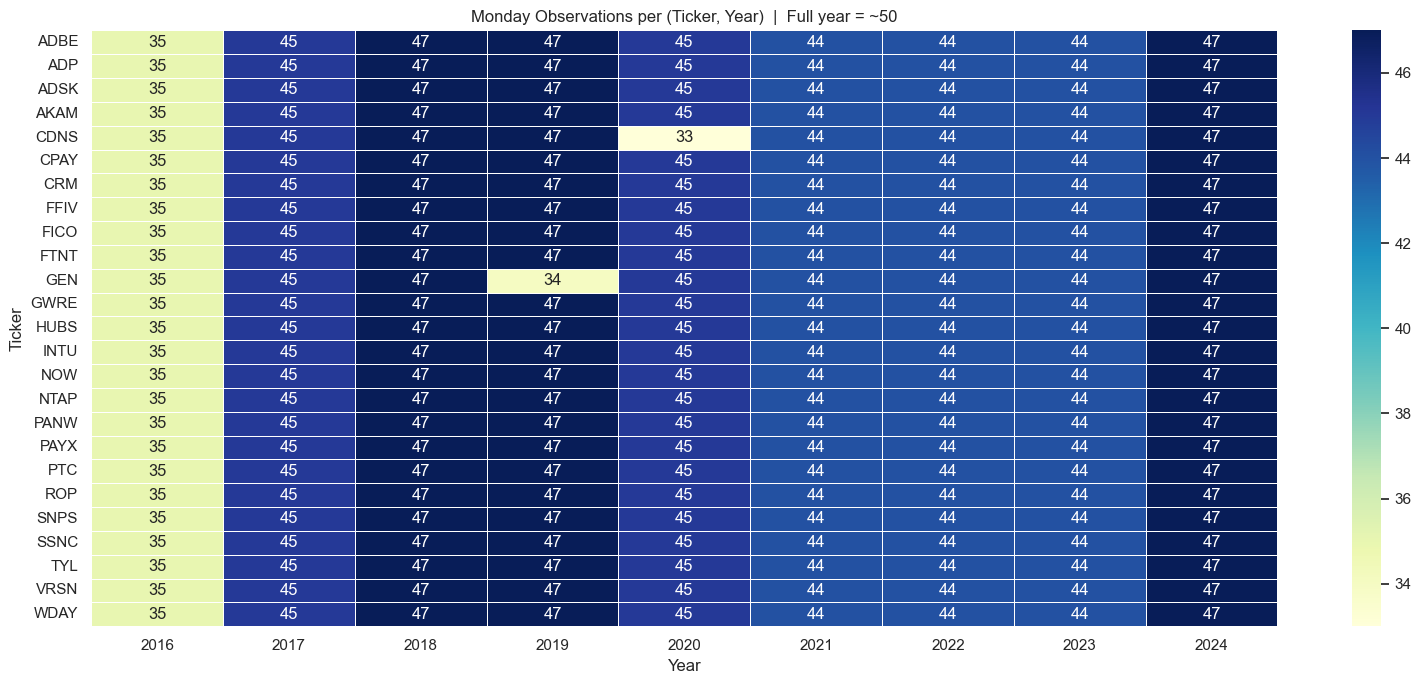

In [6]:
# Coverage heatmap: Monday observations per (Ticker, Year).
# A full year should have ~50 Mondays. Cells well below 50 indicate missing data.
# This is important for walk-forward validation: if a ticker has very few rows
# in the early training window, its influence on the model during those years is small.
year_counts = df.groupby(['Year', 'Ticker']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(year_counts.T, annot=True, fmt='d', cmap='YlGnBu', ax=ax, linewidths=0.5)
ax.set_title('Monday Observations per (Ticker, Year)  |  Full year = ~50')
ax.set_xlabel('Year')
ax.set_ylabel('Ticker')
plt.tight_layout()
plt.show()

## 3. Target Variable Analysis

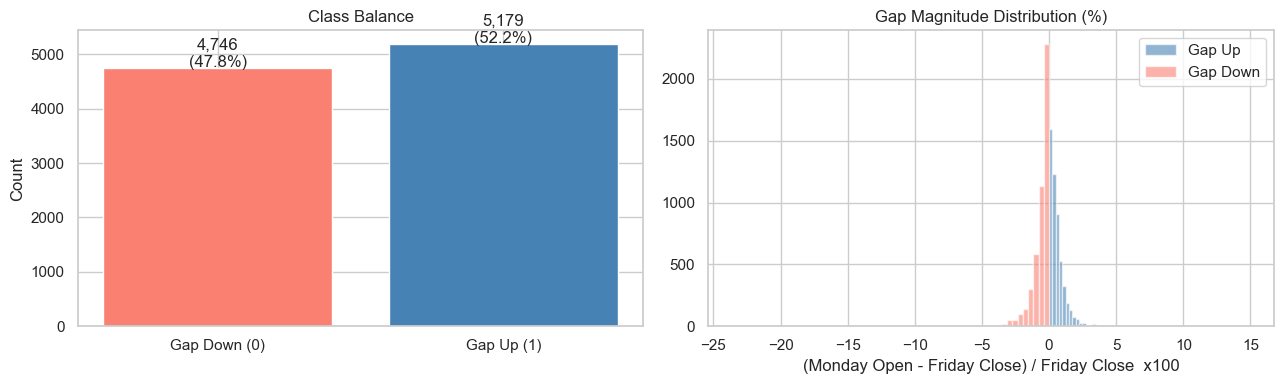

Gap Up rate:   0.522
Gap Down rate: 0.478

Gap magnitude stats (%):
count    9925.0000%
mean       -0.0173%
std         1.2001%
min       -23.4499%
25%        -0.3870%
50%         0.0272%
75%         0.4661%
max        14.8373%
Name: GapMagnitude, dtype: object


In [ ]:
# Class balance and gap magnitude distribution.
#

gap_counts = df['GapUp'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(['Gap Down (0)', 'Gap Up (1)'], gap_counts.values, color=['salmon', 'steelblue'])
axes[0].set_title('Class Balance')
axes[0].set_ylabel('Count')
for i, v in enumerate(gap_counts.values):
    axes[0].text(i, v + 20, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')

axes[1].hist(df.loc[df['GapUp']==1, 'GapMagnitude'].dropna()*100, bins=60, alpha=0.6, label='Gap Up', color='steelblue')
axes[1].hist(df.loc[df['GapUp']==0, 'GapMagnitude'].dropna()*100, bins=60, alpha=0.6, label='Gap Down', color='salmon')
axes[1].set_title('Gap Magnitude Distribution (%)')
axes[1].set_xlabel('(Monday Open - Friday Close) / Friday Close  x100')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Gap Up rate:   {gap_counts[1]/gap_counts.sum():.3f}')
print(f'Gap Down rate: {gap_counts[0]/gap_counts.sum():.3f}')
print(f'\nGap magnitude stats (%):')
print((df['GapMagnitude']*100).describe().apply(lambda x: f'{x:.4f}%'))

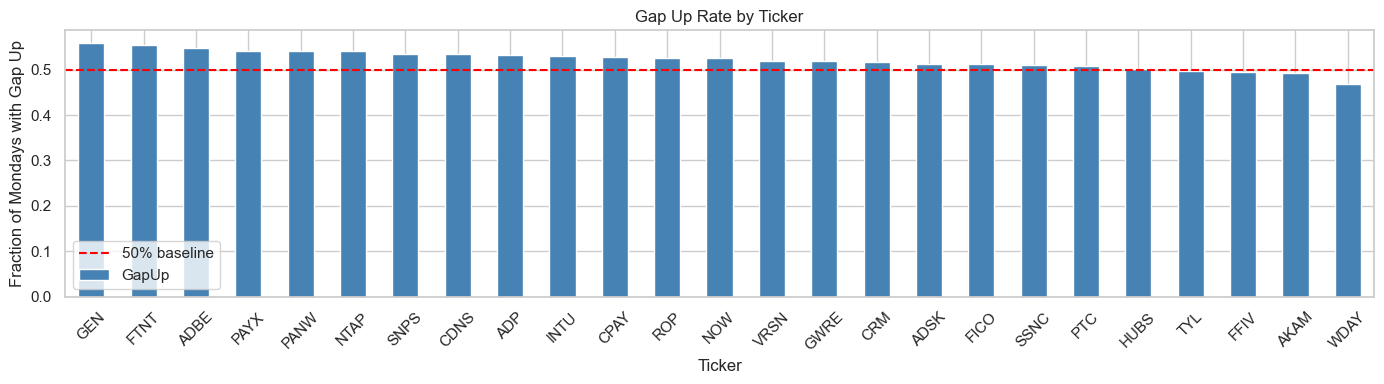

In [ ]:
# Gap up rate per ticker.
gap_by_ticker = df.groupby('Ticker')['GapUp'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 4))
gap_by_ticker.plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(0.5, color='red', linestyle='--', label='50% baseline')
ax.set_title('Gap Up Rate by Ticker')
ax.set_ylabel('Fraction of Mondays with Gap Up')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

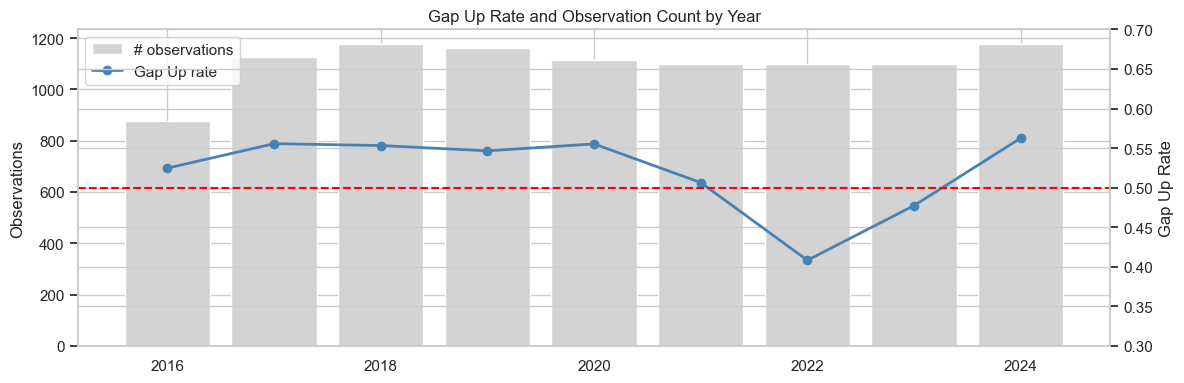

In [ ]:
# Gap up rate per year — checks for temporal drift in the target distribution.

gap_by_year = df.groupby('Year')['GapUp'].agg(['mean', 'count'])
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(gap_by_year.index, gap_by_year['count'], color='lightgrey', label='# observations')
ax1.set_ylabel('Observations')
ax2 = ax1.twinx()
ax2.plot(gap_by_year.index, gap_by_year['mean'], 'o-', color='steelblue', linewidth=2, label='Gap Up rate')
ax2.axhline(0.5, color='red', linestyle='--')
ax2.set_ylabel('Gap Up Rate')
ax2.set_ylim(0.3, 0.7)
ax1.set_title('Gap Up Rate and Observation Count by Year')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

## 4. Missing Value Deep-Dive

Before touching any missing values, we must understand **why** they are missing. The cause determines the correct fix:

| Type | Cause | Strategy |
|------|--------|----------|
| **Warmup NaNs** | Rolling window indicators (RSI=14, ADX=14, Bollinger=20) need N prior rows before producing a value. Missing at the start of each ticker's history only. | Drop those rows — they are structurally unusable and cannot be imputed without look-ahead bias. |
| **First-week NaNs** | Price aggregates (WeeklyReturn, FridayPosition) require a prior week. First Monday per ticker has nothing to compare to. | Already handled by the target variable step — drop remaining. |
| **Structural fundamental NaNs** | Many software companies do not separately report Cost of Revenues in SEC filings. The pipeline's XBRL tag lookup found no match. | Do NOT impute with a global median — the absence is informative (these companies tend to have very high margins). Use ticker-level median + missingness indicator flag. |
| **Liabilities NaN** | XBRL tag varies across filers; pipeline didn't catch all aliases. | Same as above. |

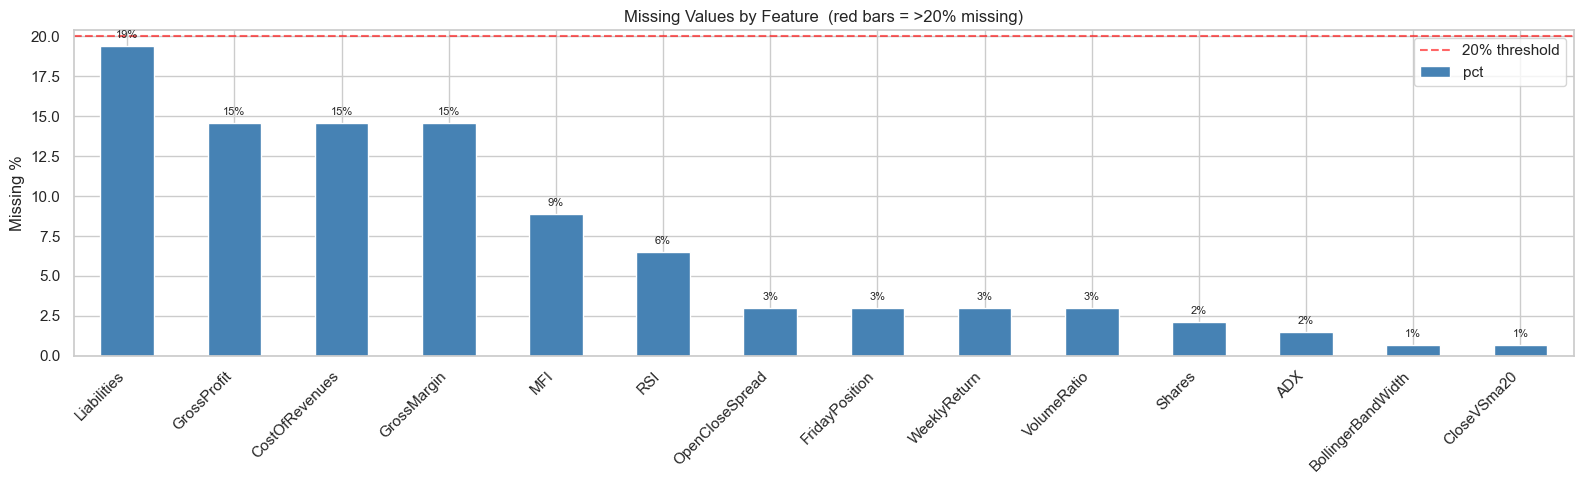

,count,pct
Liabilities,1926,19.4
GrossProfit,1453,14.6
CostOfRevenues,1453,14.6
GrossMargin,1453,14.6
MFI,884,8.9
RSI,643,6.5
OpenCloseSpread,300,3.0
FridayPosition,300,3.0
WeeklyReturn,300,3.0
VolumeRatio,300,3.0


In [ ]:
# Define feature groups used throughout the notebook.

technical_features   = ['RSI', 'MACD', 'ROC', 'StochPercK',
                         'CloseVEma50', 'CloseVSma20', 'ADX',
                         'BollingerBandWidth', 'ATR', 'FiveDStdDev',
                         'OBV', 'MFI', 'VolumeRatio']
price_agg_features   = ['WeeklyReturn', 'IntraWeekVolatility', 'WeeklyRange',
                         'FridayPosition', 'OpenCloseSpread']
fundamental_features = ['GrossMargin', 'NetMargin', 'RoA', 'RevGrowthQoQ']
raw_fund_cols        = ['Revenues', 'CostOfRevenues', 'GrossProfit', 'NetIncome',
                         'Assets', 'Liabilities', 'Equity', 'Shares']

all_features = technical_features + price_agg_features + fundamental_features

# Overall missing % per feature across the working dataset
all_cols_to_check = all_features + raw_fund_cols
missing     = df[all_cols_to_check].isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_df  = pd.DataFrame({'count': missing, 'pct': missing_pct}).query('count > 0')

fig, ax = plt.subplots(figsize=(16, 5))
colors = ['salmon' if p > 20 else 'steelblue' for p in missing_df['pct']]
missing_df['pct'].plot(kind='bar', ax=ax, color=colors)
ax.axhline(20, color='red', linestyle='--', alpha=0.6, label='20% threshold')
ax.set_title('Missing Values by Feature  (red bars = >20% missing)')
ax.set_ylabel('Missing %')
ax.legend()
for i, (idx, row) in enumerate(missing_df.iterrows()):
    ax.text(i, row['pct'] + 0.5, f"{row['pct']:.0f}%", ha='center', fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(missing_df)

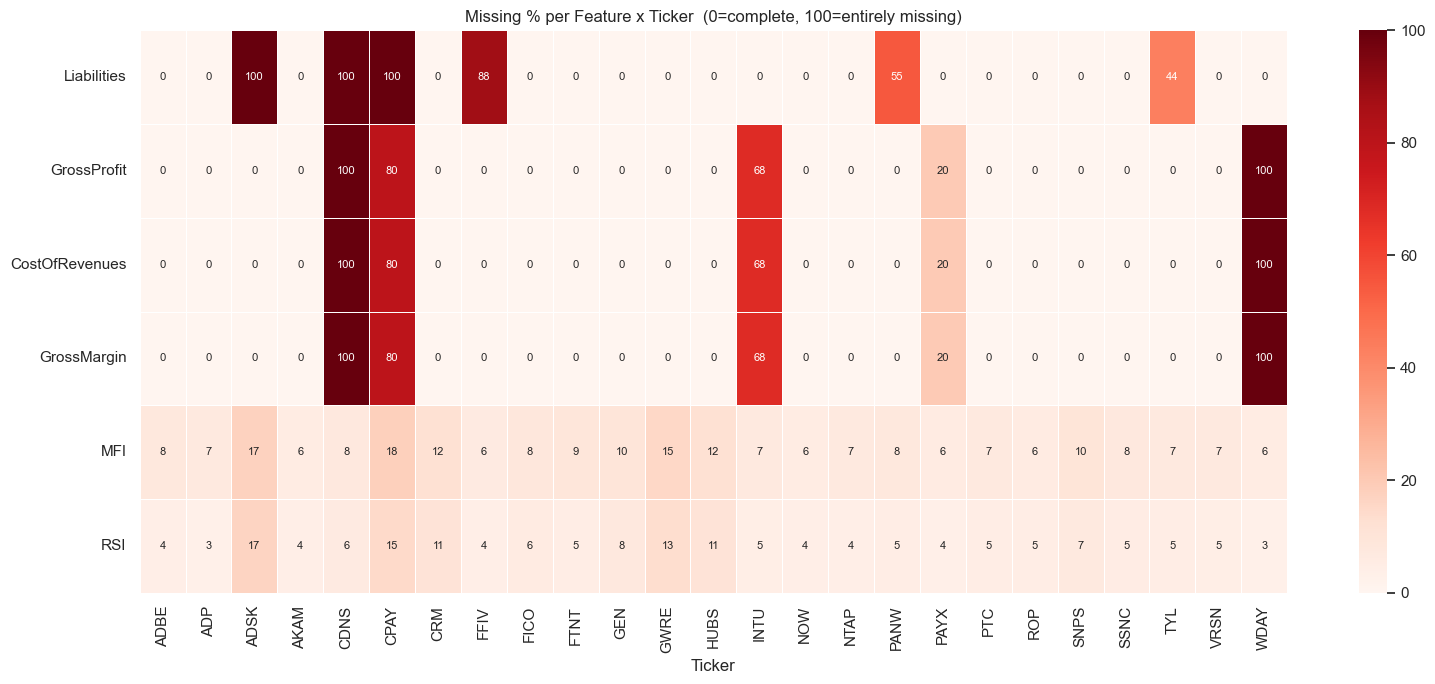

In [ ]:
# Are missing values concentrated in specific tickers?

high_missing_cols = missing_df[missing_df['pct'] > 5].index.tolist()
miss_by_ticker    = df[high_missing_cols].isnull().groupby(df['Ticker']).mean() * 100

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(miss_by_ticker.T, annot=True, fmt='.0f', cmap='Reds', ax=ax,
            linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Missing % per Feature x Ticker  (0=complete, 100=entirely missing)')
plt.tight_layout()
plt.show()

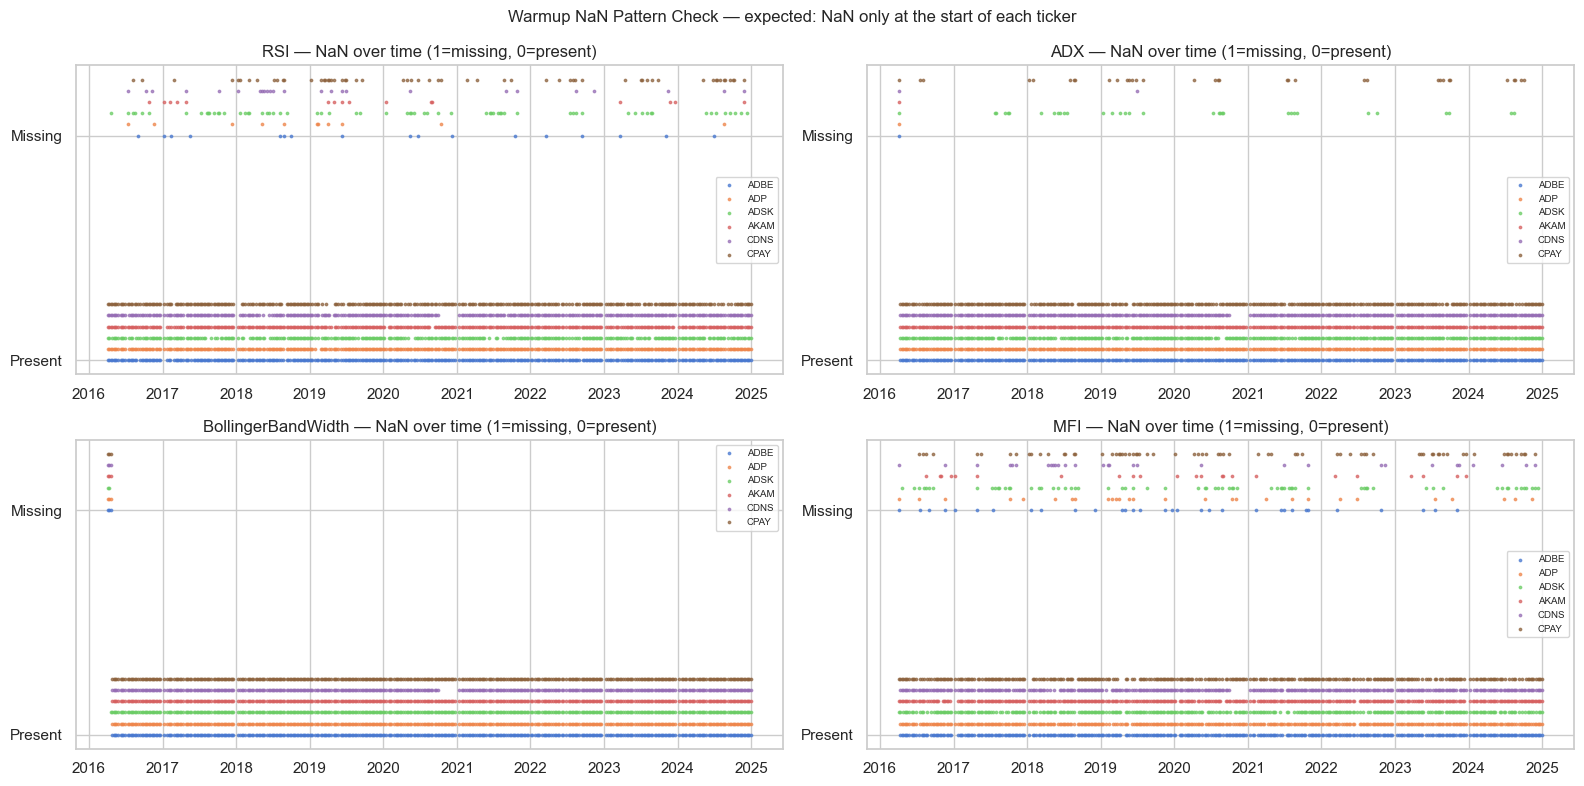

In [ ]:
# Check whether rolling-indicator NaNs are concentrated at the start of each

warmup_features  = ['RSI', 'ADX', 'BollingerBandWidth', 'MFI']
sample_tickers   = sorted(df['Ticker'].unique())[:6]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()
for i, feat in enumerate(warmup_features):
    ax = axes[i]
    for j, ticker in enumerate(sample_tickers):
        sub     = df[df['Ticker'] == ticker][['Date_notz', feat]].reset_index(drop=True)
        is_null = sub[feat].isnull().astype(int)
        ax.scatter(sub['Date_notz'], is_null + j*0.05, s=3, alpha=0.7, label=ticker)
    ax.set_title(f'{feat} — NaN over time (1=missing, 0=present)')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Present', 'Missing'])
    ax.legend(fontsize=7)

plt.suptitle('Warmup NaN Pattern Check — expected: NaN only at the start of each ticker', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Missing Value Handling

**Decision rules applied here:**
1. **Warmup NaNs** — drop rows where core technical indicators are NaN. These rows have no usable signal. We do not forward-fill because that would use a stale indicator value from potentially weeks ago, creating look-ahead bias.
2. **Structural fundamental NaNs** — add a missingness indicator column (binary flag), then fill remaining NaN with ticker-level median. The indicator preserves the information that 'this company doesn't report this metric'.
3. **Remaining NaNs in other features** — drop rows if any core features still have NaN after the above steps.

In [ ]:
# Step 1: Add missingness indicator columns for structural fundamental NaNs.
structural_missing = [c for c in ['GrossMargin', 'CostOfRevenues', 'Liabilities'] if c in df.columns]
for col in structural_missing:
    df[f'{col}_missing'] = df[col].isnull().astype(int)

print('Missingness indicator columns added:')
indicator_cols = [f'{c}_missing' for c in structural_missing]
print(df[indicator_cols].sum().to_string())

Missingness indicator columns added:
GrossMargin_missing       1453
CostOfRevenues_missing    1453
Liabilities_missing       1926


In [ ]:
# Step 2: Fill fundamental NaNs with ticker-level median.
fund_to_impute = [c for c in ['GrossMargin', 'NetMargin', 'RoA', 'RevGrowthQoQ',
                               'CostOfRevenues', 'Liabilities', 'GrossProfit']
                  if c in df.columns]

before_missing = df[fund_to_impute].isnull().sum()
df[fund_to_impute] = df.groupby('Ticker')[fund_to_impute].transform(
    lambda x: x.fillna(x.median())
)
after_missing  = df[fund_to_impute].isnull().sum()

impute_report = pd.DataFrame({'before': before_missing, 'after': after_missing})
impute_report['filled'] = impute_report['before'] - impute_report['after']
print('Fundamental imputation (ticker-level median):')
display(impute_report[impute_report['before'] > 0])

Fundamental imputation (ticker-level median):


,before,after,filled
GrossMargin,1453,784,669
CostOfRevenues,1453,784,669
Liabilities,1926,1182,744
GrossProfit,1453,784,669


In [ ]:
# Step 3: Drop rows where core technical indicators are NaN (warmup rows).
core_tech   = ['RSI', 'ADX', 'BollingerBandWidth', 'MFI']
before_drop = len(df)
df_clean    = df.dropna(subset=core_tech).copy()
after_drop  = len(df_clean)

print(f'Rows before dropping warmup NaNs: {before_drop:,}')
print(f'Rows after:                        {after_drop:,}')
print(f'Dropped:                           {before_drop - after_drop:,}  ({(before_drop-after_drop)/before_drop*100:.1f}%)')

Rows before dropping warmup NaNs: 9,925
Rows after:                        8,715
Dropped:                           1,210  (12.2%)


In [ ]:
# Step 3b: Fallback imputation for tickers where the entire GrossMargin column is NaN.

tickers_fully_missing_gm = df_clean.groupby('Ticker')['GrossMargin'].apply(lambda x: x.isnull().all())
tickers_fully_missing_gm = tickers_fully_missing_gm[tickers_fully_missing_gm].index.tolist()

global_gm_median = df_clean[~df_clean['Ticker'].isin(tickers_fully_missing_gm)]['GrossMargin'].median()
df_clean['GrossMargin'] = df_clean['GrossMargin'].fillna(global_gm_median)

print(f'Tickers with 100% GrossMargin missing: {tickers_fully_missing_gm}')
print(f'Global GrossMargin median used as fallback: {global_gm_median:.4f}')
print(f'GrossMargin NaNs remaining: {df_clean["GrossMargin"].isnull().sum()}')

Tickers with 100% GrossMargin missing: ['CDNS', 'WDAY']
Global GrossMargin median used as fallback: 0.7550
GrossMargin NaNs remaining: 0


In [ ]:
# Step 3c: Drop holiday-week rows — weeks where price aggregate features cannot be computed.

price_agg_required = ['WeeklyReturn', 'FridayPosition', 'OpenCloseSpread', 'VolumeRatio']
before_holiday_drop = len(df_clean)
df_clean = df_clean.dropna(subset=price_agg_required).copy()

print(f'Dropped holiday-week rows: {before_holiday_drop - len(df_clean)}')
print(f'Rows remaining: {len(df_clean):,}')
print(f'GapUp rate: {df_clean["GapUp"].mean():.3f}')

Dropped holiday-week rows: 278
Rows remaining: 8,437
GapUp rate: 0.514


In [ ]:
# Step 3d: Add an extreme event indicator for the COVID crash period (Feb-May 2020).

df_clean['is_extreme_event'] = (
    (df_clean['Date'] >= '2020-02-01') & (df_clean['Date'] <= '2020-05-31')
).astype(int)

extreme_rows = df_clean[df_clean['is_extreme_event'] == 1]
normal_rows  = df_clean[df_clean['is_extreme_event'] == 0]
print(f'Total rows:                                    {len(df_clean):,}')
print(f'Rows flagged as extreme event (COVID window):  {df_clean["is_extreme_event"].sum()}')
print(f'Of those, gaps >5%:                            {(extreme_rows["GapMagnitude"].abs() > 0.05).sum()}')
print(f'Primary training set (excl. extreme events):   {len(normal_rows):,}')
print(f'GapUp rate (primary):                          {normal_rows["GapUp"].mean():.3f}')
print(f'GapUp rate (extreme events only):              {extreme_rows["GapUp"].mean():.3f}')

Total rows:                                    8,437
Rows flagged as extreme event (COVID window):  291
Of those, gaps >5%:                            51
Primary training set (excl. extreme events):   8,146
GapUp rate (primary):                          0.516
GapUp rate (extreme events only):              0.450


In [ ]:
# Step 5: Confirm no remaining NaNs in the feature columns we plan to use.
remaining_missing = df_clean[all_features].isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

if len(remaining_missing) == 0:
    print('No remaining missing values in feature columns.')
else:
    print('Remaining missing values — investigate before modelling:')
    display(pd.DataFrame({'count': remaining_missing,
                          'pct': (remaining_missing/len(df_clean)*100).round(2)}))

print(f'\nFinal clean dataset shape: {df_clean.shape}')
print(f'GapUp distribution after cleaning:')
print(df_clean['GapUp'].value_counts().to_string())
print(f'GapUp rate: {df_clean["GapUp"].mean():.3f}')

No remaining missing values in feature columns.

Final clean dataset shape: (8437, 49)
GapUp distribution after cleaning:
GapUp
1    4337
0    4100
GapUp rate: 0.514


## 6. Feature Distributions by Class

For each feature, we compare its distribution between GapUp=1 and GapUp=0 using overlapping histograms. Differences in mean, spread, or shape suggest predictive signal. All histograms are clipped at the 1st/99th percentile so extreme outliers don't flatten the main distribution.

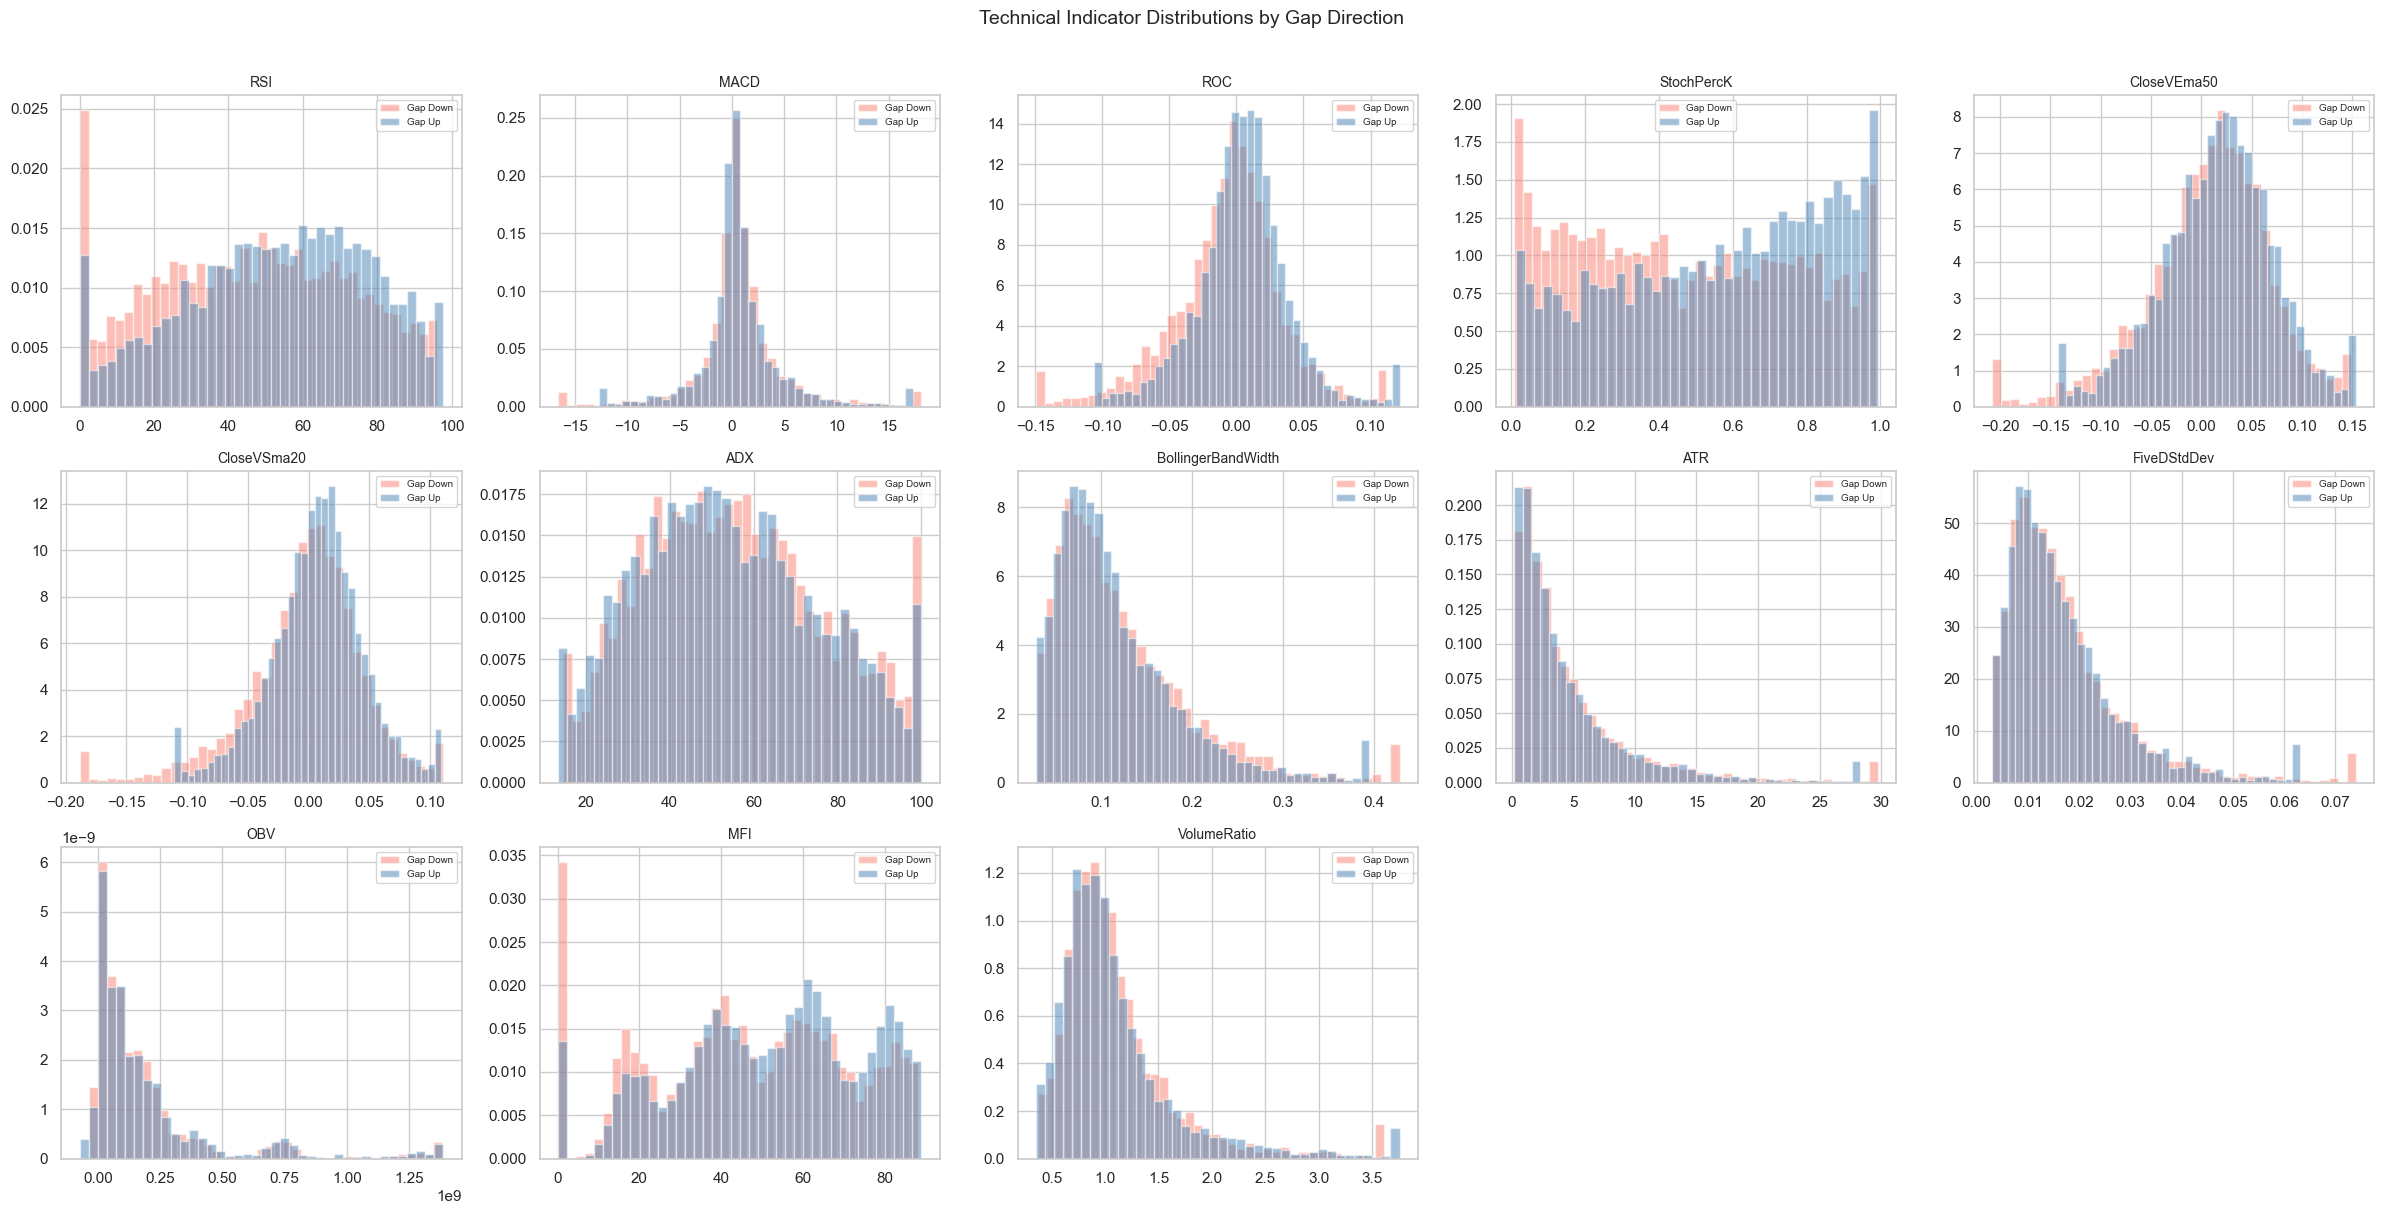

In [ ]:
# Technical indicator distributions by gap direction.


fig, axes = plt.subplots(3, 5, figsize=(24, 12))
axes = axes.flatten()

for i, feat in enumerate(technical_features):
    ax = axes[i]
    for label, color, name in [(0, 'salmon', 'Gap Down'), (1, 'steelblue', 'Gap Up')]:
        vals = df_clean.loc[df_clean['GapUp'] == label, feat].dropna()
        lo, hi = vals.quantile(0.01), vals.quantile(0.99)
        vals = vals.clip(lo, hi)
        ax.hist(vals, bins=40, alpha=0.5, label=name, color=color, density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=7)

for j in range(len(technical_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Technical Indicator Distributions by Gap Direction', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

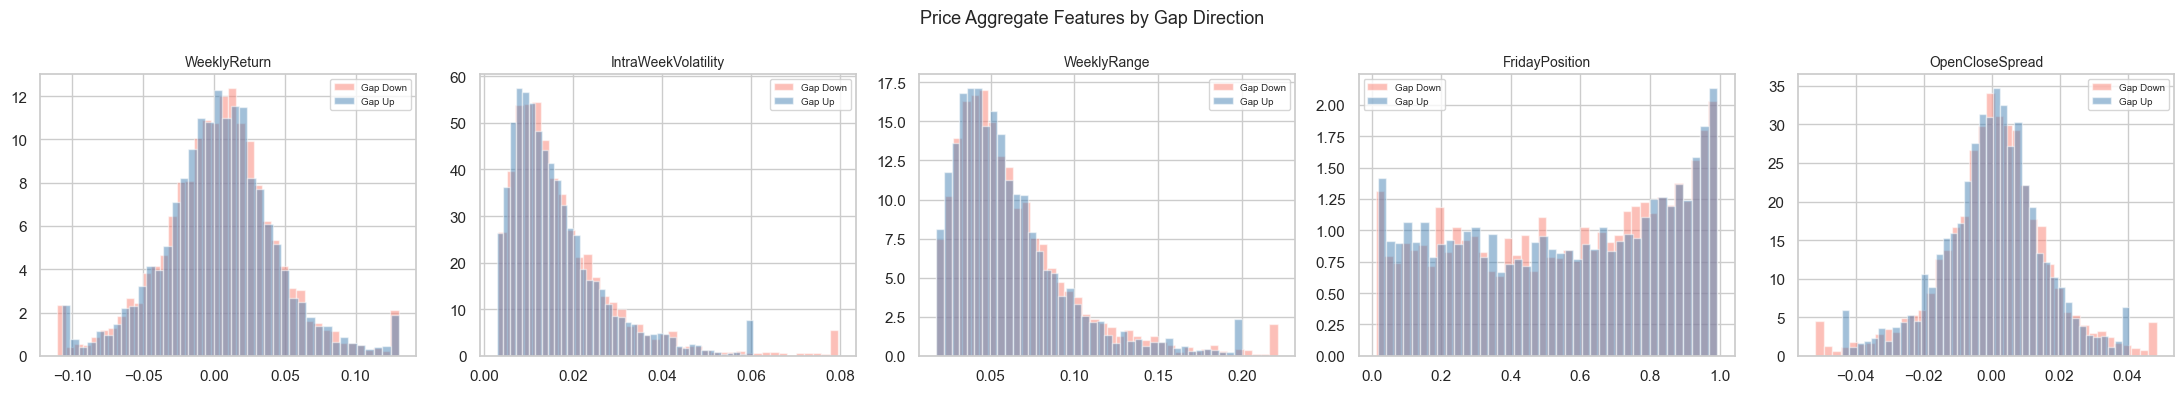

In [ ]:
# Price aggregate features.

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, feat in enumerate(price_agg_features):
    ax = axes[i]
    for label, color, name in [(0, 'salmon', 'Gap Down'), (1, 'steelblue', 'Gap Up')]:
        vals = df_clean.loc[df_clean['GapUp'] == label, feat].dropna()
        lo, hi = vals.quantile(0.01), vals.quantile(0.99)
        vals = vals.clip(lo, hi)
        ax.hist(vals, bins=40, alpha=0.5, label=name, color=color, density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=7)
plt.suptitle('Price Aggregate Features by Gap Direction', fontsize=13)
plt.tight_layout()
plt.show()

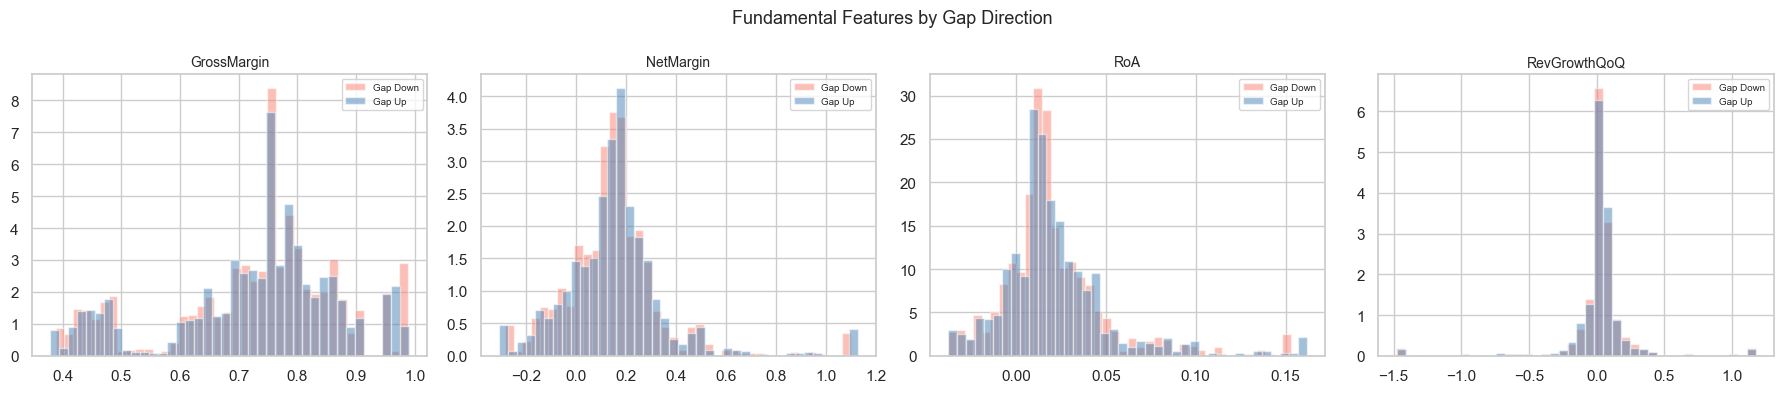

In [ ]:
# Fundamental features.
# These are quarterly values — they repeat for all weeks within a quarter
# for a given ticker. =
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, feat in enumerate(fundamental_features):
    ax = axes[i]
    for label, color, name in [(0, 'salmon', 'Gap Down'), (1, 'steelblue', 'Gap Up')]:
        vals = df_clean.loc[df_clean['GapUp'] == label, feat].dropna()
        lo, hi = vals.quantile(0.01), vals.quantile(0.99)
        vals = vals.clip(lo, hi)
        ax.hist(vals, bins=40, alpha=0.5, label=name, color=color, density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=7)
plt.suptitle('Fundamental Features by Gap Direction', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Summary Statistics and Effect Sizes

We compare the mean of each feature between the two classes. `Diff %` is the percentage difference in means — a rough linear effect size. Features near 0 are unlikely to help a linear model (logistic regression), but may still help tree or sequence models if the relationship is non-linear.

In [ ]:
# Mean comparison table sorted by absolute effect size.

stats = []
for feat in all_features:
    up   = df_clean.loc[df_clean['GapUp']==1, feat].dropna()
    down = df_clean.loc[df_clean['GapUp']==0, feat].dropna()
    diff = up.mean() - down.mean()
    pct_diff = diff / abs(down.mean()) * 100 if down.mean() != 0 else np.nan
    stats.append({
        'Feature':              feat,
        'Mean (GapUp=1)':       round(up.mean(), 4),
        'Mean (GapUp=0)':       round(down.mean(), 4),
        'Diff':                 round(diff, 4),
        'Diff %':               round(pct_diff, 1),
        'Missing % (post-clean)': round(df_clean[feat].isnull().mean()*100, 1)
    })

stats_df = (pd.DataFrame(stats)
              .set_index('Feature')
              .sort_values('Diff %', key=abs, ascending=False))
display(stats_df)

,Mean (GapUp=1),Mean (GapUp=0),Diff,Diff %,Missing % (post-clean)
Feature,,,,,
CloseVSma20,6.500000e-03,-3.400000e-03,9.900000e-03,292.8,0.0
ROC,3.800000e-03,-7.000000e-03,1.080000e-02,153.6,0.0
CloseVEma50,1.630000e-02,6.800000e-03,9.500000e-03,139.7,0.0
NetMargin,9.586000e-01,4.666000e-01,4.920000e-01,105.5,0.0
OpenCloseSpread,2.000000e-04,6.000000e-04,-4.000000e-04,-64.0,0.0
RevGrowthQoQ,3.004300e+00,1.916700e+00,1.087600e+00,56.7,0.0
GrossMargin,1.512300e+00,1.038000e+00,4.743000e-01,45.7,0.0
StochPercK,5.711000e-01,4.658000e-01,1.054000e-01,22.6,0.0
RSI,5.314400e+01,4.595020e+01,7.193700e+00,15.7,0.0


## 8. Correlation Analysis

Two separate questions:
1. **Feature vs target** — which features have linear association with GapUp? (Pearson only captures linear; non-linear associations need mutual information, in next notebook)
2. **Feature vs feature** — which features are redundant? High inter-feature correlation (multicollinearity) degrades logistic regression coefficient stability and makes it hard to interpret which features actually matter.

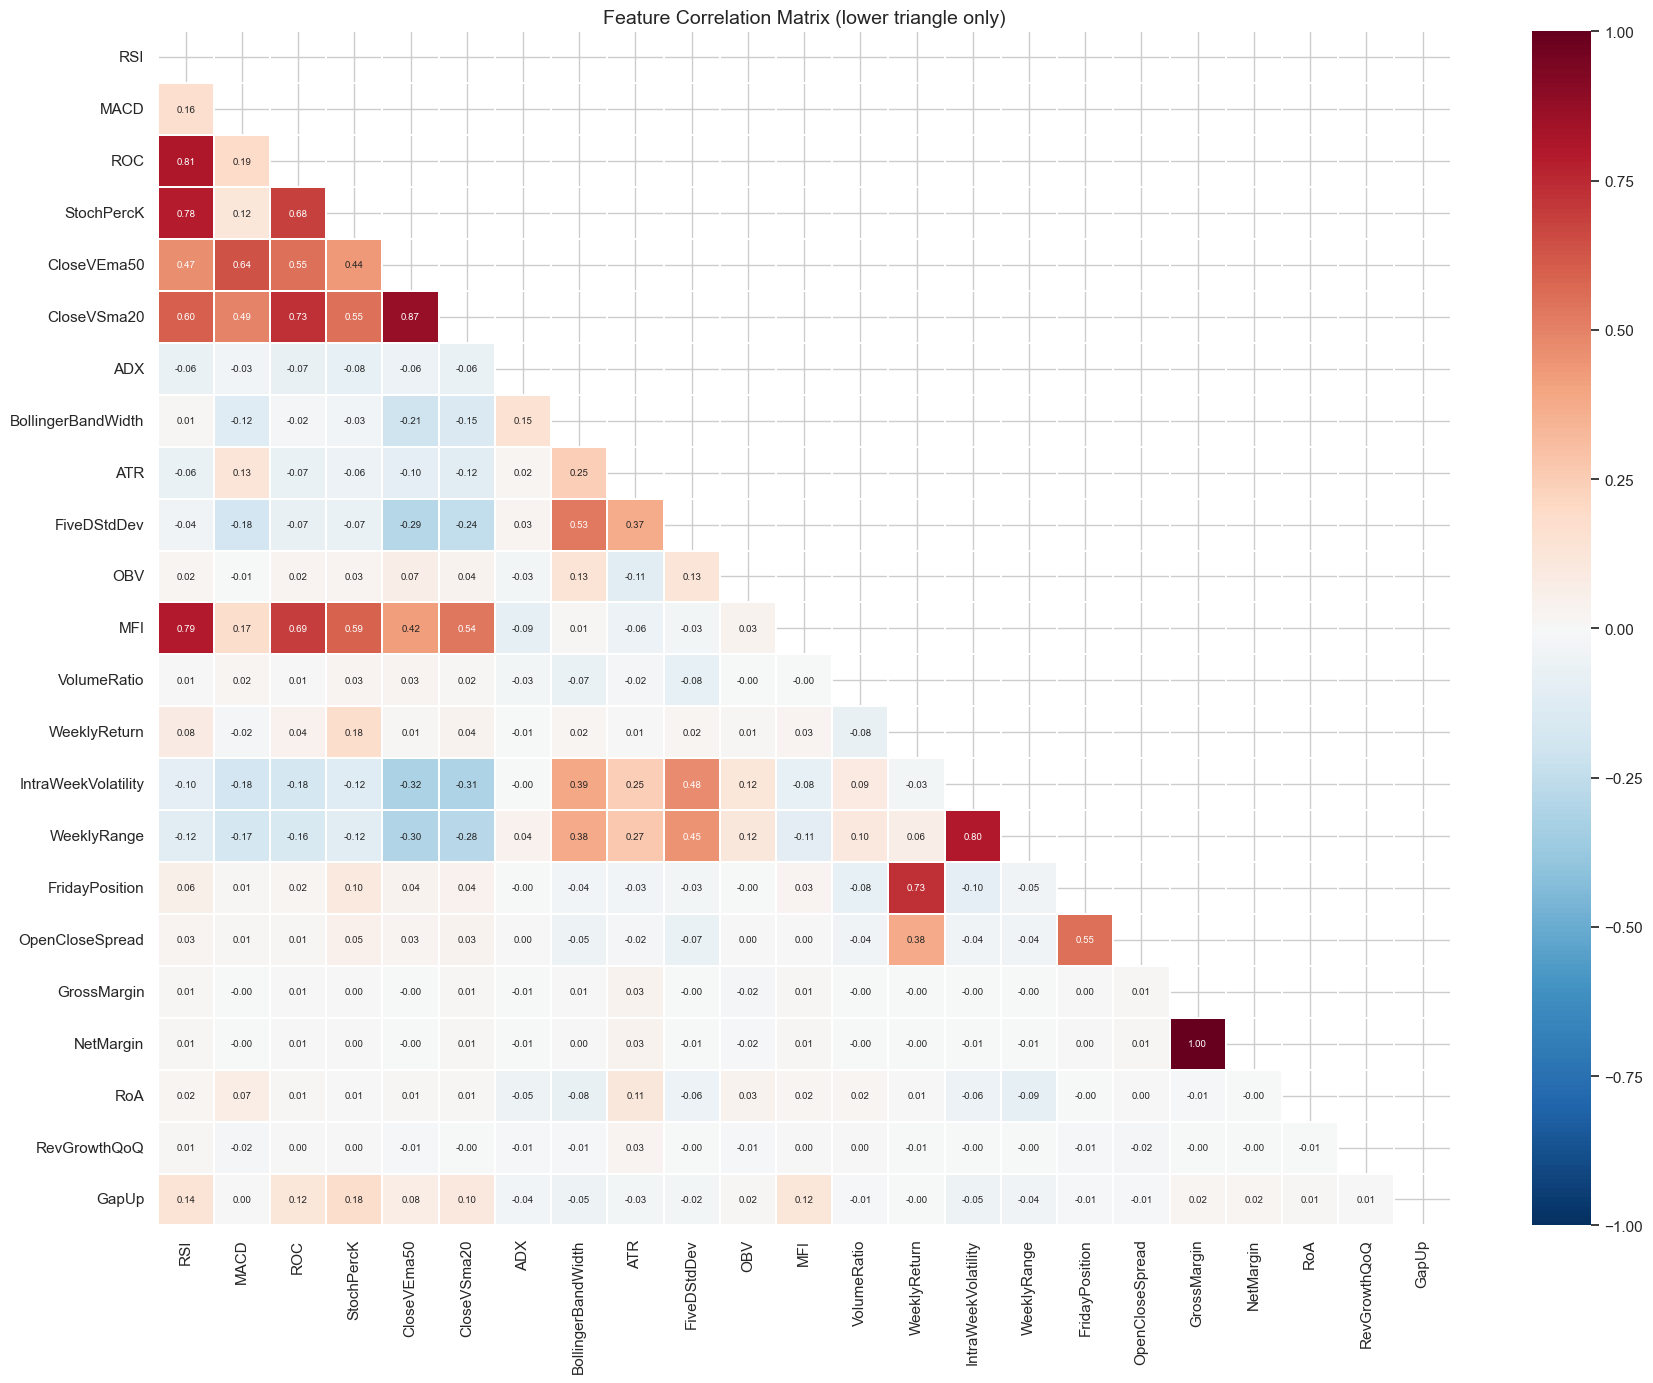

In [ ]:
# Full Pearson correlation matrix.
# The diagonal is always 1 (a feature is perfectly correlated with itself).
# Deep blue = strong positive correlation, deep red = strong negative.

corr_df = df_clean[all_features + ['GapUp']].dropna()
corr    = corr_df.corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.3, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix (lower triangle only)', fontsize=14)
plt.tight_layout()
plt.show()

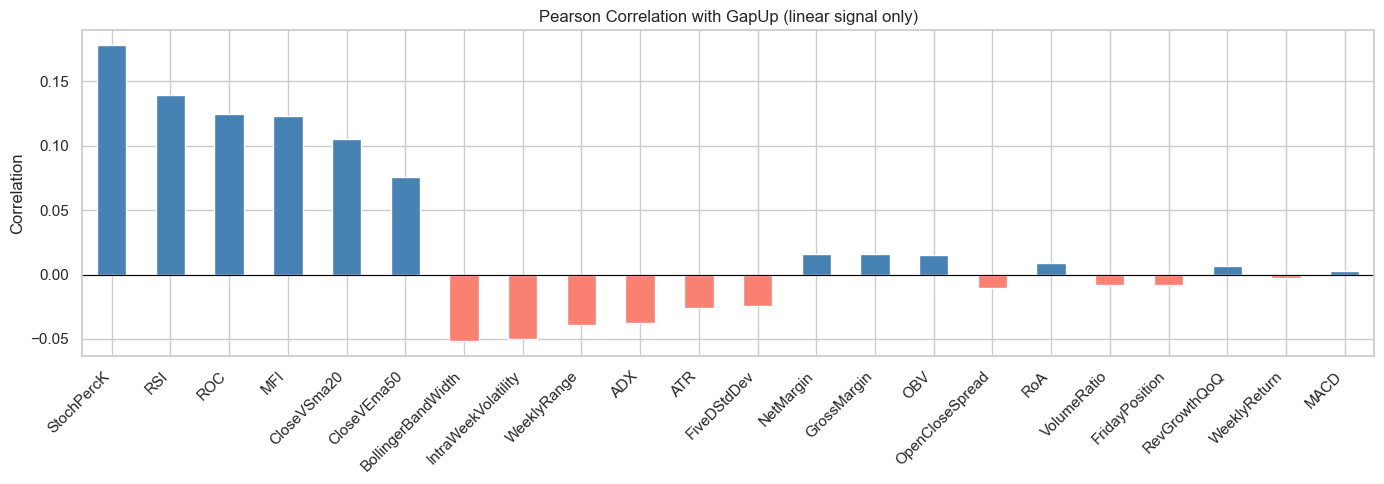

Top 10 features by absolute Pearson correlation with GapUp:


,Corr with GapUp
StochPercK,0.177997
RSI,0.139591
ROC,0.124571
MFI,0.123368
CloseVSma20,0.104888
CloseVEma50,0.076027
BollingerBandWidth,-0.051665
IntraWeekVolatility,-0.049767
WeeklyRange,-0.039293
ADX,-0.038006


In [ ]:
# Feature-to-target correlations, ranked by absolute value.
target_corr = corr['GapUp'].drop('GapUp').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['steelblue' if v > 0 else 'salmon' for v in target_corr.values]
target_corr.plot(kind='bar', ax=ax, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with GapUp (linear signal only)')
ax.set_ylabel('Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 10 features by absolute Pearson correlation with GapUp:')
display(target_corr.head(10).to_frame('Corr with GapUp'))

In [ ]:
# Identify highly correlated feature pairs — the multicollinearity list.

corr_feats = df_clean[all_features].dropna().corr()
upper      = corr_feats.where(np.triu(np.ones(corr_feats.shape), k=1).astype(bool))
high_corr  = upper.stack().abs().sort_values(ascending=False)
high_corr  = high_corr[high_corr > 0.7]

print(f'Feature pairs with |correlation| > 0.7:')
if len(high_corr) == 0:
    print('None found.')
else:
    hc_df = high_corr.rename('|correlation|').reset_index()
    hc_df.columns = ['Feature A', 'Feature B', '|correlation|']
    display(hc_df)

Feature pairs with |correlation| > 0.7:


,Feature A,Feature B,|correlation|
0,GrossMargin,NetMargin,0.999491
1,CloseVEma50,CloseVSma20,0.867301
2,RSI,ROC,0.810459
3,IntraWeekVolatility,WeeklyRange,0.799804
4,RSI,MFI,0.792735
5,RSI,StochPercK,0.781583
6,WeeklyReturn,FridayPosition,0.733031
7,ROC,CloseVSma20,0.730138


## 9. Temporal Patterns

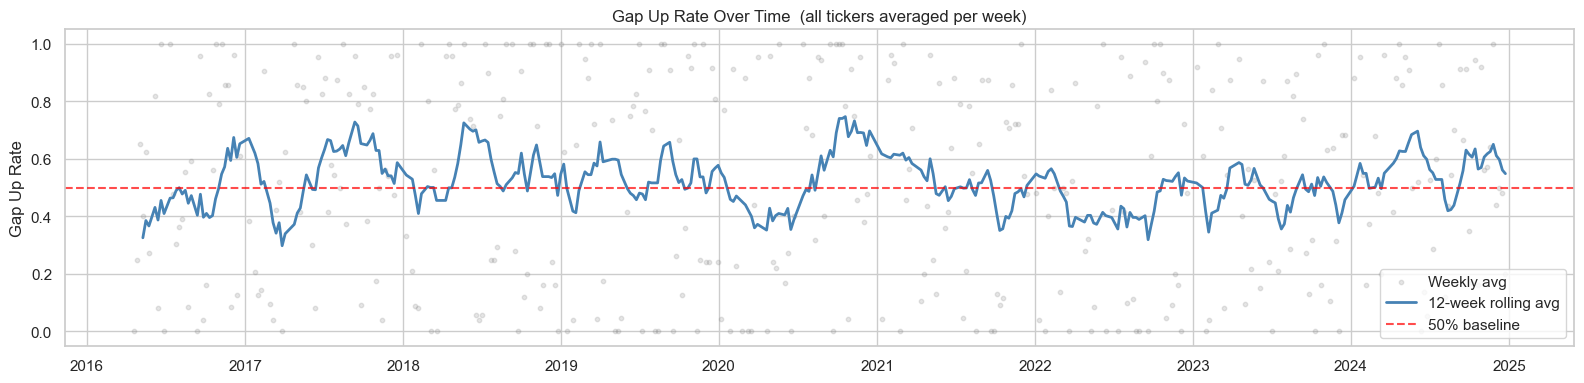

In [ ]:
# Rolling 12-week gap up rate across all tickers.
df_sorted = df_clean.sort_values('Date_notz')
weekly    = df_sorted.groupby('Date_notz')['GapUp'].mean().reset_index()
weekly['RollingGapUp'] = weekly['GapUp'].rolling(12, min_periods=4).mean()

fig, ax = plt.subplots(figsize=(16, 4))
ax.scatter(weekly['Date_notz'], weekly['GapUp'], alpha=0.2, s=10, color='grey', label='Weekly avg')
ax.plot(weekly['Date_notz'], weekly['RollingGapUp'], color='steelblue', linewidth=2, label='12-week rolling avg')
ax.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='50% baseline')
ax.set_title('Gap Up Rate Over Time  (all tickers averaged per week)')
ax.set_ylabel('Gap Up Rate')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

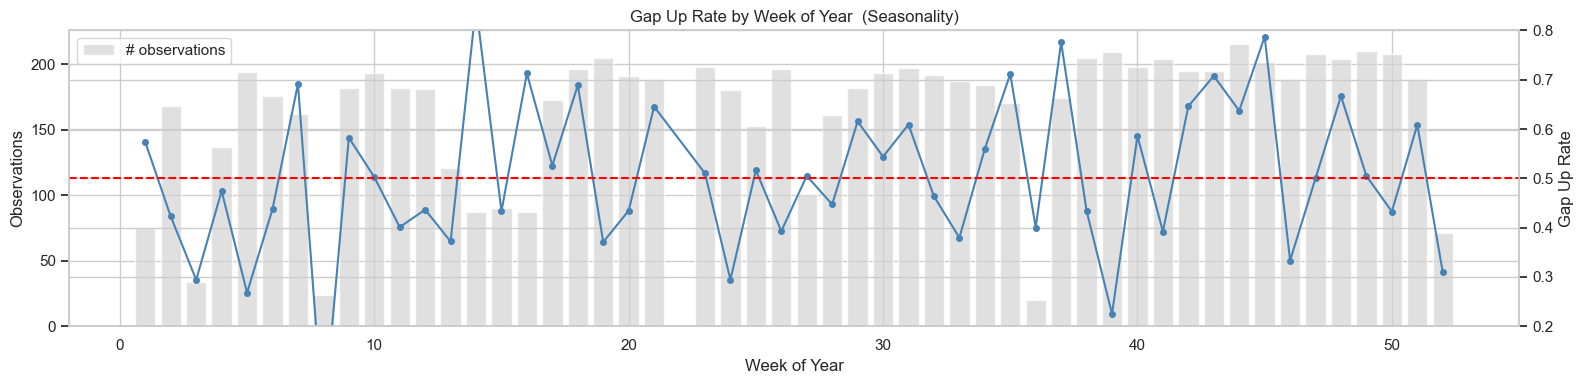

In [ ]:
# Gap up rate by week of year — seasonality check.
gap_by_week = df_clean.groupby('WeekOfYear')['GapUp'].agg(['mean', 'count'])

fig, ax1 = plt.subplots(figsize=(16, 4))
ax1.bar(gap_by_week.index, gap_by_week['count'], color='lightgrey', alpha=0.7, label='# observations')
ax2 = ax1.twinx()
ax2.plot(gap_by_week.index, gap_by_week['mean'], 'o-', color='steelblue', linewidth=1.5, markersize=4)
ax2.axhline(0.5, color='red', linestyle='--')
ax2.set_ylim(0.2, 0.8)
ax1.set_xlabel('Week of Year')
ax1.set_ylabel('Observations')
ax2.set_ylabel('Gap Up Rate')
ax1.set_title('Gap Up Rate by Week of Year  (Seasonality)')
ax1.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 10. Outlier Detection

In financial data, outliers usually have a specific cause — earnings announcements, index events, macro shocks. Identifying them matters because:
- **Logistic regression** is sensitive to outliers in feature values (they pull coefficients)
- **XGBoost** is largely robust to feature outliers (splits around them), but extreme target-adjacent events can still skew leaf predictions
- **LSTM** can have exploding/vanishing gradients from extreme input values — normalization helps but extreme outliers should be flagged

In [ ]:

threshold = 0.05
extreme   = df_clean[df_clean['GapMagnitude'].abs() > threshold][
    ['Date_notz', 'Ticker', 'Open', 'PrevFriClose', 'GapMagnitude', 'GapUp']
].sort_values('GapMagnitude', key=abs, ascending=False)

print(f'Extreme gaps (>+/-{threshold*100:.0f}%): {len(extreme):,} rows  ({len(extreme)/len(df_clean)*100:.1f}% of dataset)')
display(extreme.head(20))

Extreme gaps (>+/-5%): 69 rows  (0.8% of dataset)


,Date_notz,Ticker,Open,PrevFriClose,GapMagnitude,GapUp
19901,2020-03-16 04:00:00,ROP,231.765956,302.763702,-0.234499,0
9459,2020-03-16 04:00:00,FICO,250.000000,303.549988,-0.176412,0
3546,2017-12-18 05:00:00,AKAM,66.330002,57.759998,0.148373,1
390,2020-03-16 04:00:00,ADBE,288.359985,335.500000,-0.140507,0
20806,2020-03-16 04:00:00,SNPS,112.589996,129.880005,-0.133123,0
17594,2023-08-21 04:00:00,PANW,118.250000,104.845001,0.127855,1
15551,2020-03-16 04:00:00,NOW,50.202000,57.534000,-0.127438,0
10315,2020-03-16 04:00:00,FTNT,14.508000,16.528000,-0.122217,0
16407,2020-03-16 04:00:00,NTAP,30.801386,34.782619,-0.114460,0
1269,2020-03-16 04:00:00,ADP,112.462379,126.900040,-0.113772,0


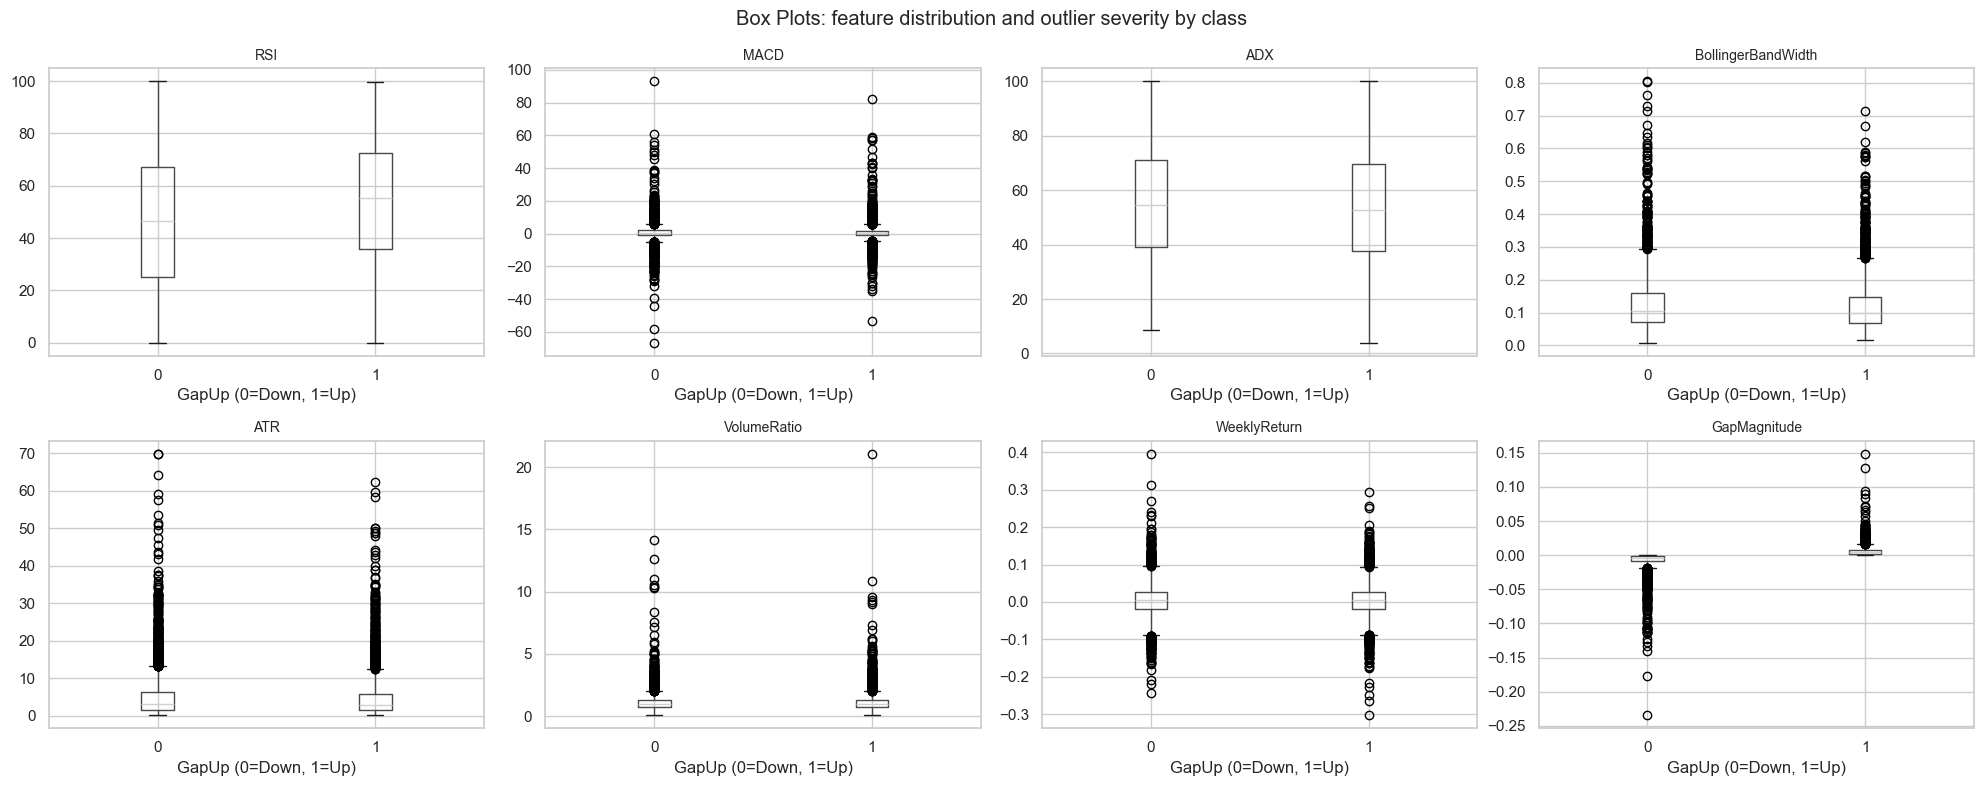

In [ ]:
# Box plots of key features split by GapUp class.
spot_features = ['RSI', 'MACD', 'ADX', 'BollingerBandWidth',
                 'ATR', 'VolumeRatio', 'WeeklyReturn', 'GapMagnitude']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, feat in enumerate(spot_features):
    df_clean.boxplot(column=feat, by='GapUp', ax=axes[i])
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('GapUp (0=Down, 1=Up)')

plt.suptitle('Box Plots: feature distribution and outlier severity by class')
plt.tight_layout()
plt.show()

## 11. Save Clean Dataset

In [ ]:
# Summary of the clean dataset before saving.

print('=== Clean Dataset Summary ===')
print(f'Shape:              {df_clean.shape}')
print(f'Tickers:            {df_clean["Ticker"].nunique()}')
print(f'Date range:         {df_clean["Date_notz"].min().date()} to {df_clean["Date_notz"].max().date()}')
print()
print('=== Target Variable ===')
print(f'Gap Up (1):    {(df_clean["GapUp"]==1).sum():,}  ({(df_clean["GapUp"]==1).mean()*100:.1f}%)')
print(f'Gap Down (0):  {(df_clean["GapUp"]==0).sum():,}  ({(df_clean["GapUp"]==0).mean()*100:.1f}%)')
print(f'Gap magnitude median:  {df_clean["GapMagnitude"].median()*100:.3f}%')
print(f'Gap magnitude std:     {df_clean["GapMagnitude"].std()*100:.3f}%')
print(f'Extreme gaps (>5%):    {(df_clean["GapMagnitude"].abs() > 0.05).sum():,}')
print()
print('=== Feature Groups ===')
print(f'Technical indicators ({len(technical_features)}):  {technical_features}')
print(f'Price aggregates ({len(price_agg_features)}):      {price_agg_features}')
print(f'Fundamentals ({len(fundamental_features)}):        {fundamental_features}')
miss_indicators = [c for c in df_clean.columns if c.endswith('_missing')]
print(f'Missingness indicators ({len(miss_indicators)}):   {miss_indicators}')
print()
print('=== Remaining Missing Values ===')
rem = df_clean[all_features].isnull().sum()
rem = rem[rem > 0]
print('None.' if len(rem) == 0 else rem.to_string())

=== Clean Dataset Summary ===
Shape:              (8437, 49)
Tickers:            25
Date range:         2016-04-18 to 2024-12-23

=== Target Variable ===
Gap Up (1):    4,337  (51.4%)
Gap Down (0):  4,100  (48.6%)
Gap magnitude median:  0.017%
Gap magnitude std:     1.221%
Extreme gaps (>5%):    69

=== Feature Groups ===
Technical indicators (13):  ['RSI', 'MACD', 'ROC', 'StochPercK', 'CloseVEma50', 'CloseVSma20', 'ADX', 'BollingerBandWidth', 'ATR', 'FiveDStdDev', 'OBV', 'MFI', 'VolumeRatio']
Price aggregates (5):      ['WeeklyReturn', 'IntraWeekVolatility', 'WeeklyRange', 'FridayPosition', 'OpenCloseSpread']
Fundamentals (4):        ['GrossMargin', 'NetMargin', 'RoA', 'RevGrowthQoQ']
Missingness indicators (3):   ['GrossMargin_missing', 'CostOfRevenues_missing', 'Liabilities_missing']

=== Remaining Missing Values ===
None.


In [32]:
# Save the clean dataset. This is the input for the statistical analysis
# and modelling notebooks. It includes the missingness indicator columns.
df_clean.to_csv('../structured_csv_data_files/fetched_data/dataset_clean.csv', index=False)
print('Saved to: structured_csv_data_files/fetched_data/dataset_clean.csv')

Saved to: structured_csv_data_files/fetched_data/dataset_clean.csv
